# 04 · Modeling

In [1]:
import sys
sys.path.insert(0, "..")

import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_curve, precision_recall_curve

from src.metrics import evaluate   # AUROC, Gini, KS, AUPRC, best F1

In [2]:
df = pd.read_csv("../data/preprocessed_train.csv")
X = df.drop(columns=["SK_ID_CURR", "TARGET"]).astype("float32")   # float32 halves memory
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(246008, 223) (61503, 223)


# 1. Logistic Regression (baseline)

In [3]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced")),
])
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
evaluate(y_test, lr_prob).round(4)

AUROC           0.7510
Gini            0.5019
KS              0.3757
AUPRC           0.2359
F1              0.3023
F1_threshold    0.6736
dtype: float64

# 2. Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
evaluate(y_test, rf_prob).round(4)

AUROC           0.7440
Gini            0.4881
KS              0.3650
AUPRC           0.2232
F1              0.2931
F1_threshold    0.5911
dtype: float64

# 3. Gradient Boosting
`HistGradientBoostingClassifier`: the fast histogram version of gradient boosting (246k rows).

In [5]:
gb = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
gb.fit(X_train, y_train)
gb_prob = gb.predict_proba(X_test)[:, 1]
evaluate(y_test, gb_prob).round(4)

AUROC           0.7678
Gini            0.5356
KS              0.4007
AUPRC           0.2586
F1              0.3218
F1_threshold    0.6669
dtype: float64

# 4. Model comparison

In [6]:
probs = {"Logistic Regression": lr_prob, "Random Forest": rf_prob, "Gradient Boosting": gb_prob}
comparison = pd.DataFrame([evaluate(y_test, p, name) for name, p in probs.items()])
comparison.sort_values("AUROC", ascending=False).round(4)

,AUROC,Gini,KS,AUPRC,F1,F1_threshold
Gradient Boosting,0.7678,0.5356,0.4007,0.2586,0.3218,0.6669
Logistic Regression,0.7510,0.5019,0.3757,0.2359,0.3023,0.6736
Random Forest,0.7440,0.4881,0.3650,0.2232,0.2931,0.5911


# 5. ROC and Precision-Recall curves

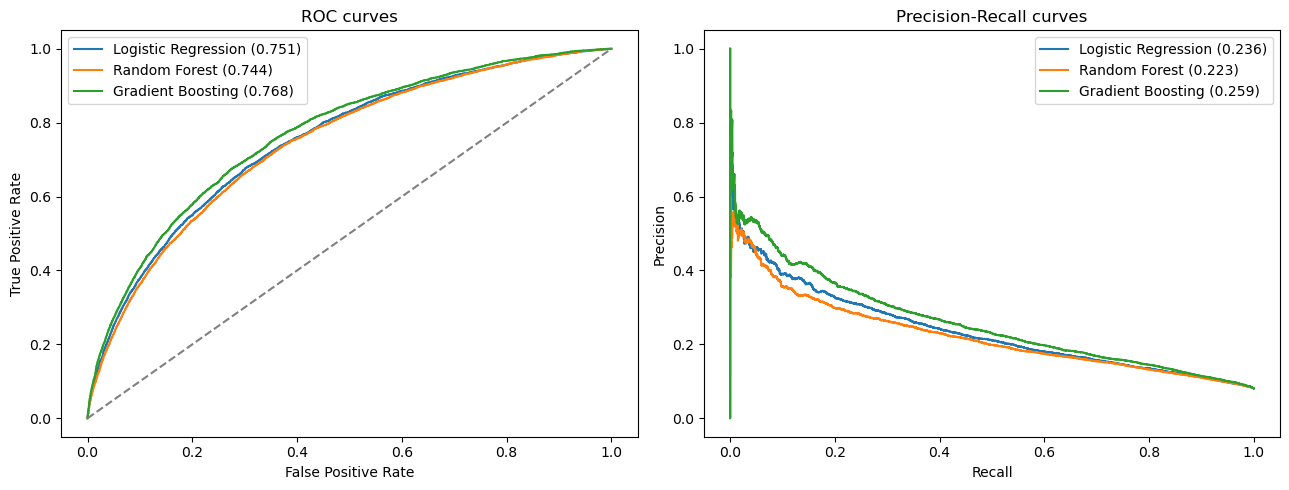

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    precision, recall, _ = precision_recall_curve(y_test, p)
    ax1.plot(fpr, tpr, label=f"{name} ({comparison.loc[name, 'AUROC']:.3f})")
    ax2.plot(recall, precision, label=f"{name} ({comparison.loc[name, 'AUPRC']:.3f})")
ax1.plot([0, 1], [0, 1], "--", color="gray")
ax1.set(title="ROC curves", xlabel="False Positive Rate", ylabel="True Positive Rate")
ax2.set(title="Precision-Recall curves", xlabel="Recall", ylabel="Precision")
ax1.legend(); ax2.legend()
plt.tight_layout()
plt.show()

# 6. Cross-validation (5-fold stratified)
No application dates in the data, so `StratifiedKFold` instead of `TimeSeriesSplit`.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, model in [("Logistic Regression", lr), ("Random Forest", rf), ("Gradient Boosting", gb)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = {"mean AUROC": scores.mean(), "std AUROC": scores.std()}
pd.DataFrame(cv_results).T.round(4)

,mean AUROC,std AUROC
Logistic Regression,0.7474,0.0024
Random Forest,0.7392,0.0023
Gradient Boosting,0.7620,0.0020


# 7. Hyperparameter tuning (Gradient Boosting)
50 random configurations × 3 folds (3 instead of 5 to keep it under an hour).

In [9]:
param_dist = {
    "learning_rate": loguniform(0.02, 0.2),
    "max_iter": randint(100, 400),
    "max_leaf_nodes": randint(15, 63),
    "min_samples_leaf": randint(20, 200),
    "l2_regularization": loguniform(1e-3, 10),
}
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight="balanced", early_stopping=False, random_state=42),
    param_distributions=param_dist, n_iter=50, cv=3, scoring="roc_auc", random_state=42,
)
search.fit(X_train, y_train)

best_params = {k: v.item() if hasattr(v, "item") else v for k, v in search.best_params_.items()}
print("Best params:", best_params)
print(f"Best CV AUROC: {search.best_score_:.4f}")

Best params: {'l2_regularization': 4.268407710065496, 'learning_rate': 0.03550767407304449, 'max_iter': 336, 'max_leaf_nodes': 29, 'min_samples_leaf': 190}
Best CV AUROC: 0.7637


In [10]:
best_model = search.best_estimator_
evaluate(y_test, best_model.predict_proba(X_test)[:, 1], "Gradient Boosting (tuned)").round(4)

AUROC           0.7705
Gini            0.5410
KS              0.4068
AUPRC           0.2630
F1              0.3228
F1_threshold    0.6811
Name: Gradient Boosting (tuned), dtype: float64

In [11]:
joblib.dump(best_model, "../models/best_model.pkl")
with open("../reports/tuned_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

# Summary
- **Gradient Boosting wins on AUROC (0.768) and AUPRC (0.259)**; logistic regression 0.751, random forest 0.744.
- **CV is stable**: GB 0.762 ± 0.002, so the 1.7-point lead over the baseline is real, not luck of the split.
- **Tuning**: best CV 0.764; on the test set the tuned model reaches **AUROC 0.771** (+0.003 over the default GB). Saved as `models/best_model.pkl`.